<a href="https://colab.research.google.com/github/harshithanotfound/ML_Classification_Project/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer(as_frame=True)

df = data.frame

df["target_label"] = df["target"].map({
    0: "malignant",
    1: "benign"
})

df.to_csv("breast_cancer_classification_dataset.csv", index=False)

print("CSV file created successfully")

CSV file created successfully


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report

In [21]:
df = pd.read_csv("breast_cancer_classification_dataset.csv")

print("First 5 rows:")
display(df.head())

print("Shape of dataset:")
print(df.shape)

print("Dataset information:")
df.info()

print("Summary statistics:")
display(df.describe())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


Shape of dataset:
(569, 32)
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 no

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [22]:
print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

df["target"] = df["target"].astype(int)

print("Data cleaning completed")
print("New shape:", df.shape)

Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
target_label               0
dtype: int64
Duplicate rows:
0
Data cleaning completed
N

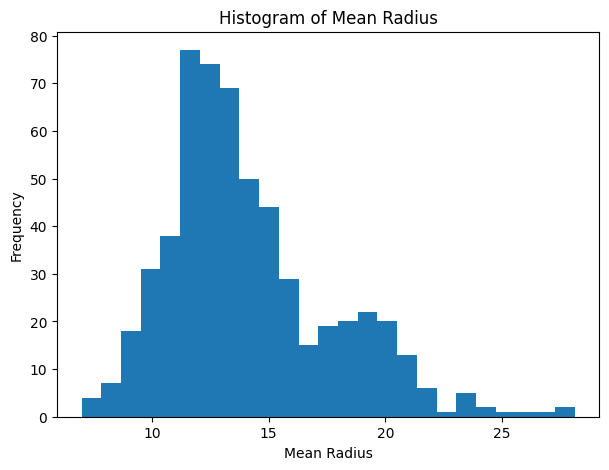

In [23]:
plt.figure(figsize=(7, 5))
plt.hist(df["mean radius"], bins=25)
plt.title("Histogram of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()

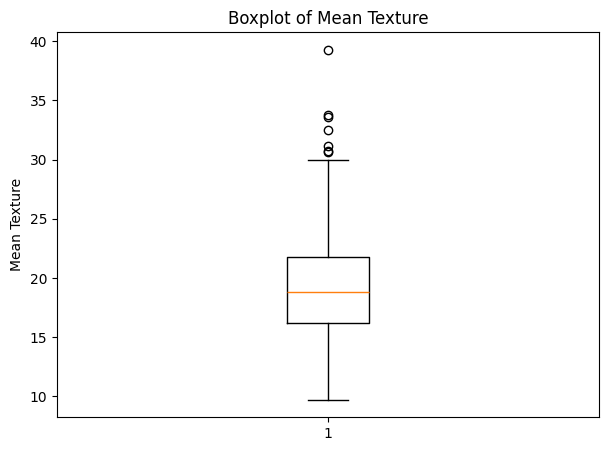

In [24]:
plt.figure(figsize=(7, 5))
plt.boxplot(df["mean texture"])
plt.title("Boxplot of Mean Texture")
plt.ylabel("Mean Texture")
plt.show()

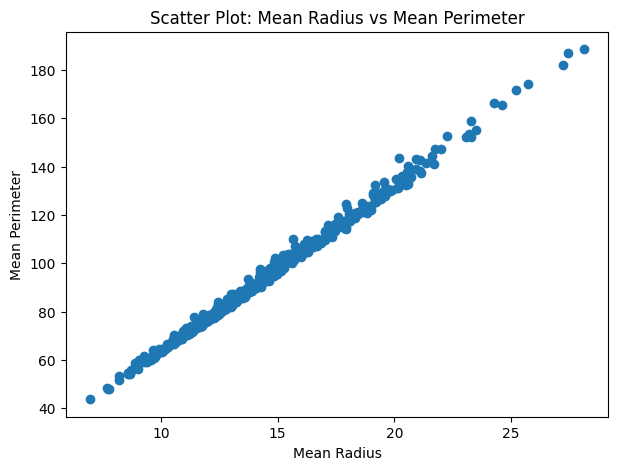

In [25]:
plt.figure(figsize=(7, 5))
plt.scatter(df["mean radius"], df["mean perimeter"])
plt.title("Scatter Plot: Mean Radius vs Mean Perimeter")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Perimeter")
plt.show()

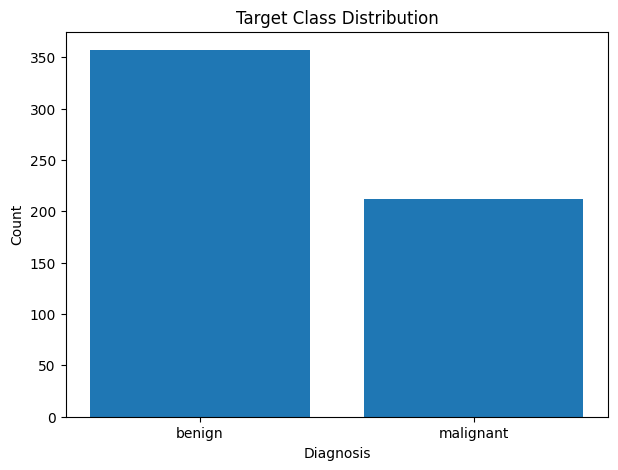

In [26]:
target_counts = df["target_label"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [27]:
X = df.drop(columns=["target", "target_label"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [28]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [30]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
])

display(results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056


In [31]:
cv_lr = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean CV Accuracy": [cv_lr.mean(), cv_rf.mean()],
    "CV Standard Deviation": [cv_lr.std(), cv_rf.std()]
})

display(cv_results)

,Model,Mean CV Accuracy,CV Standard Deviation
0,Logistic Regression,0.980686,0.006539
1,Random Forest,0.957848,0.023767


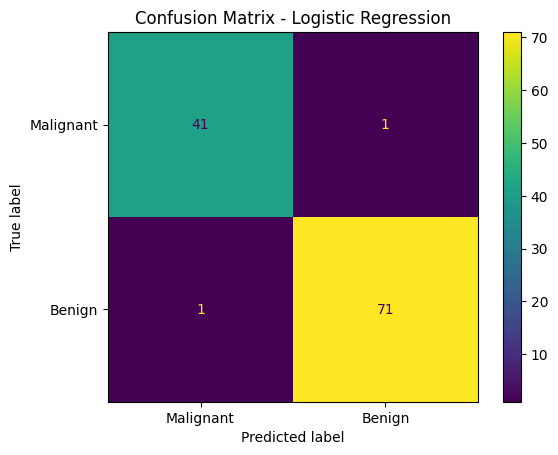

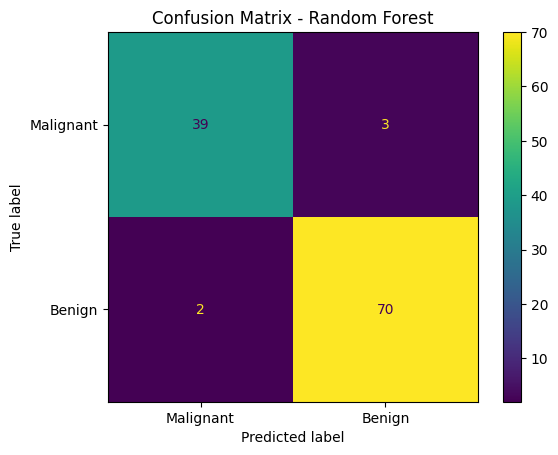

In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Malignant", "Benign"]
)

disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Malignant", "Benign"]
)

disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

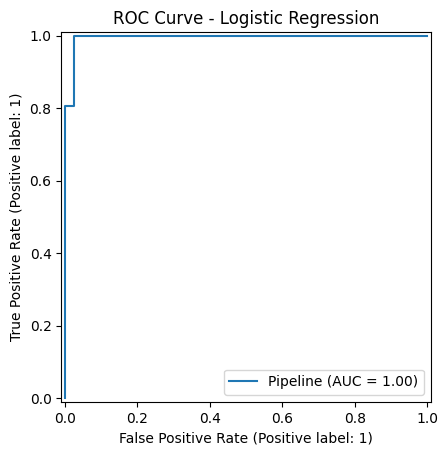

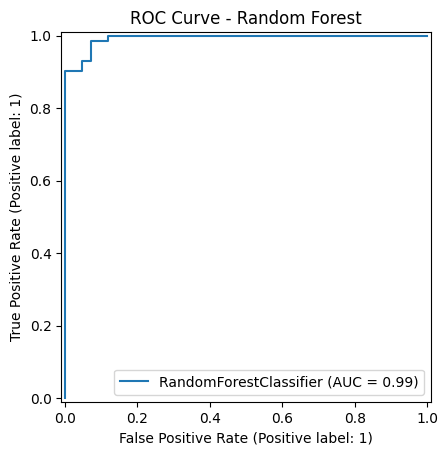

In [33]:
RocCurveDisplay.from_estimator(logistic_model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

In [34]:
print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Malignant", "Benign"]
))

print("Random Forest Classification Report")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Malignant", "Benign"]
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Random Forest Classification Report
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Conclusion:

In this project, a supervised machine learning classification model was created to predict whether a breast tumor is benign or malignant.

The dataset was loaded and checked using shape, info, and describe functions. Data cleaning was performed by checking missing values, duplicate values, and data types.

Exploratory Data Analysis was done using four plots: histogram, boxplot, scatter plot, and bar plot.

The data was divided into training and testing sets. Two algorithms were implemented: Logistic Regression and Random Forest Classifier.

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, cross-validation, confusion matrix, and ROC curve.

Both models gave good results. Logistic Regression is simple and easy to interpret, while Random Forest can handle complex patterns. The final model can be selected based on the highest F1-score and ROC-AUC score.

This project is useful in healthcare because it shows how machine learning can support doctors by helping classify tumors as benign or malignant.